# 第 32 课：降噪、SNR、AGC 与数据增强

前端增强的目标不是“声音更好听”，而是在不过度破坏语音线索的前提下提高识别鲁棒性。

<!-- course-upgrade-v2 -->
## 学习导航

| 项目 | 内容 |
|---|---|
| 所属阶段 | 音频信号前端 |
| 建议投入 | 3～5 小时，可分 2～3 次完成 |
| 前置要求 | 完成第 31 课；如果前测低于 2/3，先回看上一课小结 |
| 本课核心 | SNR、降噪、AGC与增强 |
| 完成标准 | 能口头解释核心概念；独立完成强化题；从空白重写核心函数 |

高效顺序：**先回答前测 → 预测代码结果 → 再运行 → 修改一个变量 → 关闭答案复现 → 次日回忆。**


<!-- course-upgrade-v2 -->
## 课前诊断（先不要运行代码）

1. 分别用一句话解释：SNR、降噪、AGC与增强。
2. 画出这三个概念之间的输入—输出关系。
3. 写下你最不确定的一点，并给出一个暂时猜测。

自评：答对 0～1 题先复习前置课；答对 2 题可以正常学习；3 题都能讲清楚则直接挑战代码和迁移题。


<!-- course-bridge-v3 -->
## 知识接力：先取回旧知识，再进入本课

### 3 分钟闭卷回忆

在新 Markdown cell 中回答，**不要先翻前文**：采样率、PCM、通道、RMS/dBFS、SNR；流式 chunk/cache 与时间戳。

- 三项都能用“含义 + 单位/shape + 一个数字例子”回答：进入本课。
- 能回答两项：学习本课，但把缺口记入 `LEARNING_LOG.md`。
- 只能回答零到一项：先回到 [上一课](31_音频输入质量_通道幅度DC与重采样.ipynb)与[唯一学习路径](../LEARNING_PATH.md)，做一次最小实验；不要靠继续看新术语掩盖断点。

### 本课接口契约

```text
输入：真实麦克风波形、参考信号/多通道和会话状态
  ↓ 本课要学会的变换、状态或判断
输出：保持时间映射、可旁路、可 reset 且用 CER/SNR 双重验证的前端输出
```

学完后必须能解释：输入的哪个单位/shape/状态若丢失，会让输出“仍能运行却语义错误”。


In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import soundfile as sf
import librosa

def find_root():
    here=Path.cwd().resolve()
    for p in [here,*here.parents]:
        if (p/"pyproject.toml").exists():return p
    raise FileNotFoundError("请从 learn_asr 或 notebooks 目录启动 Jupyter")
ROOT=find_root();plt.rcParams["figure.figsize"]=(11,4)
print("项目根目录:",ROOT)

from IPython.display import Audio,display
y,sr=sf.read(ROOT/"data"/"spoken_digits_parts"/"6_jackson_0.wav");y=y.astype(np.float32);rng=np.random.default_rng(2)

项目根目录: <REPO_ROOT>


## 1. 按目标 SNR 加噪

$$SNR_{dB}=10\log_{10}\frac{P_s}{P_n}$$

In [2]:
def add_noise_at_snr(clean,snr_db):
    noise=rng.normal(size=len(clean)).astype(np.float32);ps=np.mean(clean**2);pn=np.mean(noise**2)
    noise*=np.sqrt(ps/(pn*10**(snr_db/10)));return clean+noise,noise
noisy,noise=add_noise_at_snr(y,5)
print("measured SNR",10*np.log10(np.mean(y*y)/np.mean(noise*noise)))
display(Audio(noisy,rate=sr))

measured SNR 5.0


## 2. 教学版频谱门控

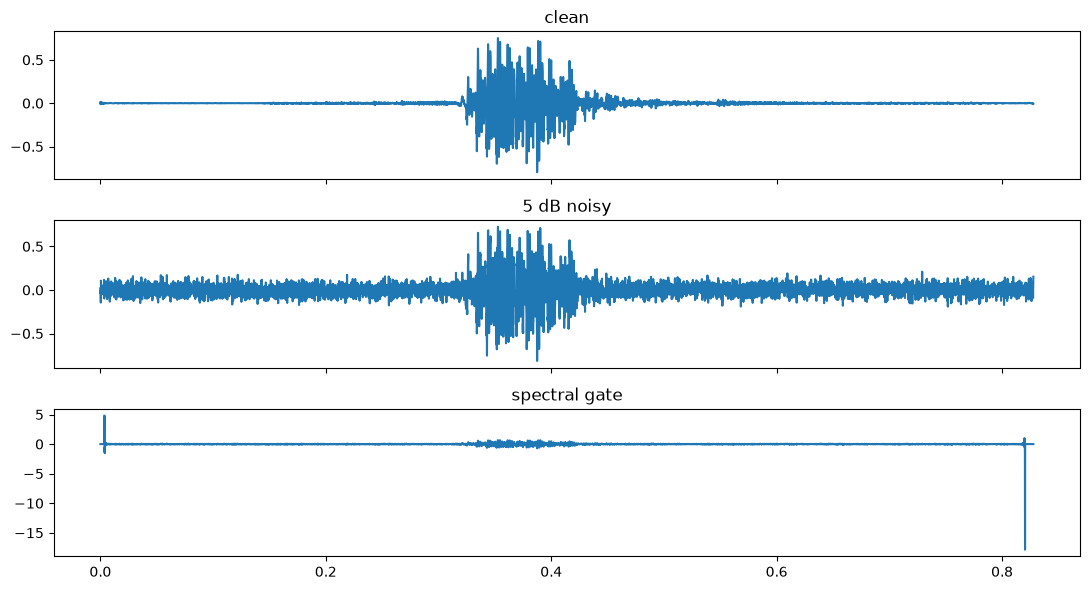

In [3]:
def spectral_gate(x,sr):
    D=librosa.stft(x,n_fft=256,hop_length=64,win_length=200,center=False);mag=np.abs(D);phase=np.exp(1j*np.angle(D))
    noise_floor=np.percentile(mag,20,axis=1,keepdims=True);gain=np.clip(1-1.5*noise_floor/(mag+1e-8),.08,1)
    return librosa.istft(mag*gain*phase,hop_length=64,win_length=200,center=False,length=len(x))
enh=spectral_gate(noisy,sr)
fig,ax=plt.subplots(3,1,figsize=(11,6),sharex=True)
for a,z,t in zip(ax,[y,noisy,enh],["clean","5 dB noisy","spectral gate"]):a.plot(np.arange(len(z))/sr,z);a.set_title(t)
plt.tight_layout();plt.show();display(Audio(enh,rate=sr))

简单 spectral gate 会产生 musical noise，并可能删除辅音等低能量语音。真实 NS 需要在目标噪声、说话人和设备上用 ASR 指标验证。

## 3. AGC：目标电平与限幅

In [4]:
def simple_agc(x,target_dbfs=-20,max_gain_db=18):
    rms=np.sqrt(np.mean(x*x)+1e-12);gain=10**((target_dbfs-20*np.log10(rms))/20);gain=min(gain,10**(max_gain_db/20))
    return np.tanh(x*gain),gain
quiet=.08*y;agc,gain=simple_agc(quiet)
print("gain",gain,"before/after RMS dBFS",20*np.log10(np.sqrt(np.mean(quiet**2))),20*np.log10(np.sqrt(np.mean(agc**2))))

gain 7.943282347242816 before/after RMS dBFS -42.029667 -24.257982


AGC 也会把静音背景噪声放大，因此通常要与 VAD、噪声估计、attack/release 平滑和 limiter 配合。训练数据增强应覆盖增益、噪声、混响、codec，而不是只加白噪声。

## 本课测试

1. SNR 从 20 dB 降到 5 dB意味着什么？
2. 降噪后听感更好是否保证 WER 更低？
3. AGC 为什么需要最大增益？
4. 数据增强与线上降噪能否互相完全替代？
5. 为什么要保留干净原始数据？

<details><summary>展开参考答案</summary>

1. 噪声相对语音强得多。2. 不保证。3. 防止静音/噪声被无限放大。4. 不能，训练鲁棒性和在线处理作用不同。5. 便于重做处理、对照和审计。

</details>

<!-- course-upgrade-v2 -->
## 强化练习：第 32 课专属题库

请先把答案写进新的 Markdown/Code cell，再展开自评标准。

### A. 基础回忆

1. 不看上文，分别定义 `SNR`、`降噪`、`AGC与增强`。
2. 哪一个量/状态是本课最容易在模块边界丢失的？它的单位和 shape 是什么？
3. 本课至少写出两个“看起来能运行，但结果其实错误”的例子。

### B. 预测与推理

4. 场景：**AGC 在静音区放大背景噪声**。先预测现象，再说明原因，最后给出一项可以验证猜测的指标。
5. 改变本课最关键参数的 0.5×、1×、2×，分别预测准确率、延迟、内存或数值误差怎样变化。
6. 画一张最小数据流图，在每条边标出 dtype、shape、时间单位或概率/代价方向。

### C. 编程与排错

7. 编程任务：**构造不同 SNR 并比较增强前后 ASR 特征**。至少加入正常、边界、错误输入三类测试。
8. 故意制造一个 off-by-one、shape、状态未 reset 或数值稳定性错误；记录错误现象和定位过程。
9. 不看本课实现，从空白 cell 重写最核心函数，并用原实现作数值对照。

### D. 迁移与表达

10. 跨课任务：**连接 NS/AGC 与 VAD 顺序**。
11. 用 90 秒向没有学过 ASR 的人解释本课；禁止只念术语，必须举一个数字或生活例子。
12. 写出一个生产系统中会监控的指标，以及它异常时优先检查的三处位置。

<details><summary>展开自评标准</summary>

- 每题 0～2 分：0=无法回答；1=方向正确但缺少单位、边界或验证；2=解释完整且能用代码/数字验证。
- 24 分满分：达到 19 分再进入下一课；15～18 分次日重做错题；低于 15 分回看本课图和核心代码。
- 第 4 题必须包含“预测—原因—指标”，第 7～9 题必须真正运行测试，第 10 题必须明确上下游 contract。
- 核心答案至少应正确使用：SNR、降噪、AGC与增强。

</details>


<!-- course-upgrade-v2 -->
## 间隔复习与离场票

### 离场票（现在完成）

- [ ] 我能不用笔记解释 SNR、降噪、AGC与增强。
- [ ] 我能说出本课最常见的错误及其观测现象。
- [ ] 我能从空白重写一个核心函数，并通过至少 3 个测试。
- [ ] 我能说明本课对上一层和下一层接口的影响。

### 复习时间表

- **明天（5 分钟）**：闭卷写出三个核心概念和一个公式/shape。
- **7 天后（15 分钟）**：重做第 4、7、10 题，不运行原答案。
- **30 天后（20 分钟）**：从真实音频或随机张量重新构造一个最小实验。

把错题记录到根目录 `LEARNING_LOG.md`。不要只写“不会”，要写：原判断、证据、正确规则、下次检查动作。
